<a href="https://colab.research.google.com/github/Annette-1/SIMULACION-1/blob/main/L%C3%ADnea_de_espera_con_un_servidor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:purple;"> **Línea de espera con un servidor**</span>

<span style="color:teal;">**Nombre:** </span> Jerónimo López Annette Michelle

<span style="color:teal;"> **Objetivo:**</span> Simular un sistema de colas M/M/1 mediante eventos discretos para analizar el comportamiento de los clientes en el sistema, estimando el tiempo promedio de permanencia y el tiempo requerido para atender a todos los clientes después de un horizonte de observación T. Asimismo, comparar los resultados obtenidos mediante simulación con las medidas teóricas del modelo de colas.

**Ejercicio:**
Del Libro de simulación de Sheldom Ross
pags 88-90, programar el sistema de Línea de Espera con un servidor.
Usar como prueba,lambda=4 y Mu=6.

Encontrar:

a) Tiempo promedio de un cliente en el sistema

b) Tiempo en que sale el último cliente.

Para simular el sistema utilizamos las siguientes variables:

* variables de tiempo $t$
* variables de conteo

$N_A:$el número de llegadas (hasta el instante $t$)

$N_D:$ el número de salidas (hasta el instante $t$ )

* Variables de estado del sistema $n:$ el número de clientes en el sistema (en el instante $t$ )

Lista de Evento esta dada de la forma:

$$LE=t_A,t_D$$

Donde:


$t_A=$ es la hora de la siguiente llegada

$t_D=$ es la hora a la que concluye el servicio
del cliente que se esta atendiendo actualmente; sino hay clientes en servicio
$t_D=∞$

Generar $T_0\to U∼(0,1)$
con $t=t- \frac{1}{λ} log U$

In [293]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

**Inicialización**

Sean $t=N_A=N_D=0$

Sea $ES=0$

Generamos $T_D$ y hacer $t_A=T_D,t_D=∞$

Con

$t=$ variablde de tiempo , $ES=n$,  $LE=t_A,t_D$

In [294]:
def generar_llegadas_poisson(lamda, T):
    """Genera tiempos de llegada para proceso Poisson homogéneo hasta T"""
    llegadas = []
    t = 0
    while t <= T:
        u = r.random()
        t = t - (1/lamda) * np.log(u)
        if t <= T:
            llegadas.append(t)
    return llegadas

In [295]:
def generar_servicio_exponencial(tasa_servicio):
    """Genera tiempo de servicio exponencial"""
    u = r.random()
    return - (1/tasa_servicio) * np.log(u)

Para ello crearemos una función que tenga los siguientes casos:

### <span style="color:red;"> Caso 1: </span>
$t_A \leq t_D,\; t_A \leq T$

Restablecer:

$$
t=t_A
$$

(nos movemos hasta el tiempo $t_A$).

Restablecer:

$$
N_A=N_A+1
$$

(pues hay una llegada adicional en el instante $t_A$).

Restablecer:

$$
n=n+1
$$

(pues ahora se tiene un cliente más).

Generar $T_n$ y hacer

$$
t_A=t_A+T_n
$$

(ésta es la hora de la siguiente llegada).

Si

$$
n=1,
$$

generar $Y$ y hacer

$$
t_D=t+Y
$$

(pues el sistema ha quedado vacío, por lo cual necesitamos generar el tiempo de servicio del nuevo cliente).

Reunir los datos de salida

$$
A(N_A)=t
$$

(pues el cliente $N_A$ llega en el instante $t$).

---

### <span style="color:purple;"> Caso 2: </span>
$t_D<t_A,\; t_D\leq T$

Restablecer:

$$
t=t_D
$$

Restablecer:

$$
n=n-1
$$

Restablecer:

$$
N_D=N_D+1
$$

(pues ha ocurrido una salida en el instante $t$).

Si

$$
n=0,
$$

hacer

$$
t_D=\infty
$$

en caso contrario, generar $Y$ y hacer

$$
t_D=t+Y.
$$

Reunir los datos de salida

$$
D(N_D)=t
$$

(pues el cliente $N_D$ acaba de salir).

---

### <span style="color:red;"> Caso 3:</span>
 $\min(t_A,t_D)>T,\; n>0$

Restablecer:

$$
t=t_D
$$

Restablecer:

$$
n=n-1
$$

Restablecer:

$$
N_D=N_D+1
$$

Si

$$
n=0,
$$

hacer

$$
t_D=\infty
$$

en caso contrario, generar $Y$ y hacer

$$
t_D=t+Y.
$$

Reunir los datos de salida

$$
D(N_D)=t
$$

(pues el cliente $N_D$ acaba de salir).

Si

$$
n>0,
$$

generar $Y$ y hacer

$$
t_D=t+Y.
$$

Reunir los datos de salida

$$
D(N_D)=t.
$$

---

### <span style="color:red;"> Caso 4:</span>
$\min(t_A,t_D)>T,\; n=0$

Reunir los datos de salida

$$
T_P=\max(t-T,\;0).
$$

Función del sistema de cola con un servidor:

    Simulamos el sistema de cola con un servidor

    Parámetros:
    lamda: tasa de llegada (Poisson)
    mu: tasa de servicio (exponencial)
    T: tiempo límite para nuevas llegadas

    Retorna:
    A: lista de tiempos de llegada
    D: lista de tiempos de salida
    TP: tiempo de salida del último cliente


In [296]:
def simular_cola(lamda, mu, T):
    # ========== INICIALIZACIÓN ==========
    t = 0.0              # tiempo actual
    NA = 0               # número de llegadas
    ND = 0               # número de salidas
    n = 0                # clientes en el sistema

    # Lista de eventos
    llegadas = generar_llegadas_poisson(lamda, T)  # todas las llegadas hasta T
    llegadas.append(float('inf'))  # centinela para evitar errores

    tA = llegadas[0]     # próxima llegada
    tD = float('inf')    # próxima salida

    # Datos de salida
    A = []               # tiempos de llegada
    D = []               # tiempos de salida
    TP = None            # tiempo último cliente
    idx_llegadas = 0     # Índice para recorrer llegadas
    # ========== BUCLE PRINCIPAL ==========
    while True:

        # CASO 1: LLEGADA (tA <= tD y tA <= T)
        if tA <= tD and tA <= T:
            t = tA
            NA += 1
            n += 1
            A.append(t)

            # Siguiente llegada
            idx_llegadas += 1
            tA = llegadas[idx_llegadas]

            # Si el servidor estaba vacío (n=1 significa que recién llegó el primero)
            if n == 1:
                Y = generar_servicio_exponencial(mu)
                tD = t + Y
        # CASO 2: SALIDA ANTES DE T (tD < tA y tD <= T)
        elif tD < tA and tD <= T:
            t = tD
            n -= 1
            ND += 1
            D.append(t)
            # Si hay más clientes en cola
            if n == 0:
                tD = float('inf')
            else:
                Y = generar_servicio_exponencial(mu)
                tD = t + Y

        # CASO 3: DESPUÉS DE T (min(tA, tD) > T y n > 0)
        elif min(tA, tD) > T and n > 0:
            t = tD
            n -= 1
            ND += 1
            D.append(t)
            if n == 0:
                tD = float('inf')
                TP = t
            else:
                Y = generar_servicio_exponencial(mu)
                tD = t + Y
        else:
            break

    # Calcular tiempo promedio en el sistema
    tiempos_sistema = []
    for i in range(min(len(A), len(D))):
        tiempo = D[i] - A[i]
        tiempos_sistema.append(tiempo)

    if tiempos_sistema:
        tiempo_promedio = np.mean(tiempos_sistema)

    if TP:
        tiempo_cierre = max(0, TP - T)

    return A, D, TP, tiempos_sistema

Creamos una función para crear las graficas de Llegadas y salidas acumuladas y Clientes en el sistema

In [297]:
def graficar_resultados(A, D, T):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # ==========================================
    # Gráfico 1: Llegadas y salidas acumuladas
    # ==========================================
    axes[0].step(A, range(1, len(A)+1),
                 where='post', label='Llegadas')
    axes[0].step(D, range(1, len(D)+1),
                 where='post', label='Salidas')

    axes[0].axvline(T, linestyle='--',
                    label=f'T = {T}')

    axes[0].set_title('Llegadas y Salidas Acumuladas')
    axes[0].set_xlabel('Tiempo')
    axes[0].set_ylabel('Clientes acumulados')
    axes[0].legend()
    axes[0].grid(True)

    # ==========================================
    # Gráfico 2: Clientes en el sistema
    # ==========================================
    eventos = []

    for t in A:
        eventos.append((t, 1))

    for t in D:
        eventos.append((t, -1))

    eventos.sort()

    tiempos = [0]
    clientes = [0]

    actual = 0

    for t, cambio in eventos:
        tiempos.append(t)
        clientes.append(actual)

        actual += cambio

        tiempos.append(t)
        clientes.append(actual)

    axes[1].step(tiempos, clientes, where='post')

    axes[1].axvline(T, linestyle='--',
                    label=f'T = {T}')

    axes[1].set_title('Clientes en el Sistema')
    axes[1].set_xlabel('Tiempo')
    axes[1].set_ylabel('Número de clientes')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

Ahora simulamos multiples llegadas para el sistema y posterior mente calcular el promedio de esto

In [298]:
def multiples_simulaciones(lamda, mu, T, n_sim=30):
    """Ejecuta múltiples simulaciones y calcula promedios"""
    tiempos_promedio = []
    tiempos_cierre = []
    total_llegadas_por_sim = []
    total_salidas_por_sim = []

    for i in range(n_sim):
        A, D, TP, tiempos_sistema = simular_cola(lamda, mu, T)
        if tiempos_sistema:
            tiempos_promedio.append(np.mean(tiempos_sistema))
        if TP:
            tiempos_cierre.append(max(0, TP - T))
        total_llegadas_por_sim.append(len(A))
        total_salidas_por_sim.append(len(D))

    print("SIMULACIÓN DE COLA CON UN SERVIDOR")
    print("="*70)
    print(f"Tasa de llegada (λ) = {lamda}")
    print(f"Tasa de servicio (μ) = {mu}")
    print(f"Tiempo límite (T) = {T}")
# Creamos unas condicinales para: Calcular el promedio y la desviación estándar
# del número total de llegadas ocurridas en cada simulación
    if total_llegadas_por_sim:
        print(f"Total de llegadas promedio: {np.mean(total_llegadas_por_sim):.2f} ± {np.std(total_llegadas_por_sim):.2f}")
    if total_salidas_por_sim:
        print(f"Total de salidas promedio: {np.mean(total_salidas_por_sim):.2f} ± {np.std(total_salidas_por_sim):.2f}")

    if tiempos_promedio:
        print(f"\nRESULTADOS PROMEDIO:")
        print(f"  a) Tiempo promedio en sistema: {np.mean(tiempos_promedio):.4f} ± {np.std(tiempos_promedio):.4f}")
    if tiempos_cierre:
        print(f"  b) Tiempo después de T hasta último cliente:: {np.mean(tiempos_cierre):.4f} ± {np.std(tiempos_cierre):.4f}")
    print("="*70)

EJECUTAMOS El PROGRAMA

Dado que tenemos varios parametros y funciones creamos un estorno para ejecutar el programa y poder mostrar las salidas correspondientes

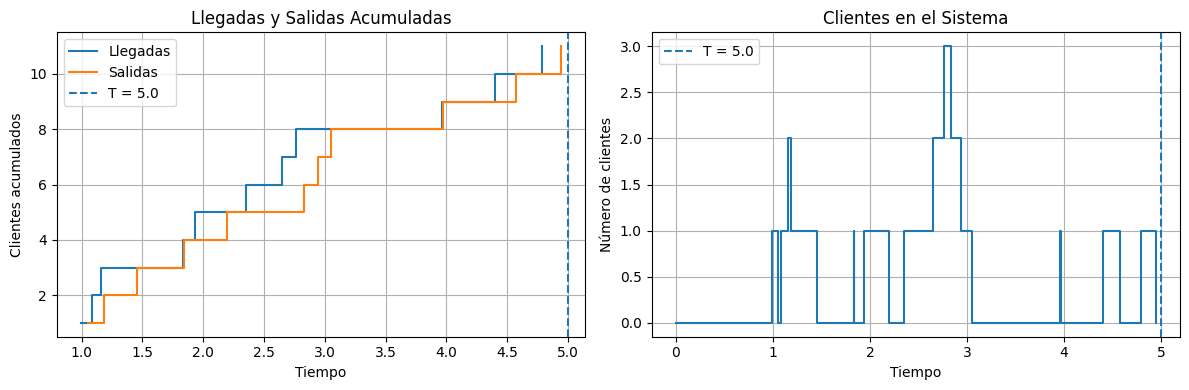

SIMULACIÓN DE COLA CON UN SERVIDOR
Tasa de llegada (λ) = 4.0
Tasa de servicio (μ) = 6.0
Tiempo límite (T) = 5.0
Total de llegadas promedio: 18.30 ± 3.95
Total de salidas promedio: 18.30 ± 3.95

RESULTADOS PROMEDIO:
  a) Tiempo promedio en sistema: 0.3809 ± 0.1937
  b) Tiempo después de T hasta último cliente:: 0.6422 ± 0.4508


In [299]:

# ========== EJECUCIÓN ==========
if __name__ == "__main__":
    # Parámetros
    lamda = 4.0    # tasa de llegada (clientes por unidad de tiempo)
    mu = 6.0      # tasa de servicio (clientes por unidad de tiempo)
    T = 5.0       # tiempo límite para llegadas

    # Una simulación detallada
    A, D, TP, tiempos = simular_cola(lamda, mu, T)

    # Graficar resultados
    graficar_resultados(A, D, T)

    # Múltiples simulaciones
    multiples_simulaciones(lamda, mu, T, n_sim=20)

<span style="color:orange;">**Solución:**

a) Tiempo promedio de un cliente en el sistema= $0.3809 ± 0.1937$

b) Tiempo en que sale el último cliente.$ 0.6422 ± 0.4508$</span>

Comprobamos la simulación de Línea de esperado usando las fórmulas:

Para un sistema **M/M/1** con:

$$
\lambda = 4
$$
$$
\mu = 6
$$

calculamos:

1. <span style="color:purple;">**Factor de utilización**</span>

$$
\rho=\frac{\lambda}{\mu}=\frac{4}{6}=0.6667
$$



In [300]:
lam = 4
mu = 6

In [301]:
# Factor de utilización
rho = lam / mu
print(f"\nρ = {rho:.4f}")


ρ = 0.6667


2. <span style="color:purple;">**Probabilidad de que no haya unidades en el sistema**</span>

$$
P_0=1-\frac{\lambda}{\mu}
$$

$$
P_0=1-\frac{4}{6}
$$

$$
P_0=0.3333
$$


In [302]:
# Probabilidad de sistema vacío
P0 = 1 - rho
print(f"P0 = {P0:.4f}")

P0 = 0.3333


3. <span style="color:purple;">**Probabilidad de que haya (n) unidades en el sistema**</span>

$$
P_n=\left(\frac{\lambda}{\mu}\right)^nP_0
$$

Por ejemplo:

$$
P_1=\left(\frac{4}{6}\right)^1(0.3333)=0.2222
$$

$$
P_2=\left(\frac{4}{6}\right)^2(0.3333)=0.1481
$$

$$
P_3=\left(\frac{4}{6}\right)^3(0.3333)=0.0988
$$

<span style="color:purple;">
<span style="color:purple;">

In [303]:
# Probabilidades Pn para n=1,2,3
for n in range(1, 4):
    Pn = (rho**n) * P0
    print(f"P({n}) = {Pn:.4f}")


P(1) = 0.2222
P(2) = 0.1481
P(3) = 0.0988


4. <span style="color:purple;">**Número promedio de unidades en cola**</span>

$$
L_q=\frac{\lambda^2}{\mu(\mu-\lambda)}
$$

$$
L_q=\frac{4^2}{6(6-4)}
$$

$$
L_q=\frac{16}{12}
$$

$$
L_q=1.3333
$$


In [304]:
# Número promedio en cola
Lq = lam**2 / (mu * (mu - lam))
print(f"Lq = {Lq:.4f}")

Lq = 1.3333


5. <span style="color:purple;"> **Número promedio de unidades en el sistema**</span>
$$
L_s=L_q+\frac{\lambda}{\mu}
$$

$$
L_s=1.3333+\frac{4}{6}
$$

$$
L_s=1.3333+0.6667
$$

$$
L_s=2
$$


In [305]:
# Número promedio en el sistema
Ls = Lq + rho
print(f"Ls = {Ls:.4f}")

Ls = 2.0000


6. <span style="color:purple;"> **Tiempo promedio que una unidad pasa en cola**</span>

$$
W_q=\frac{L_q}{\lambda}
$$

$$
W_q=\frac{1.3333}{4}
$$

$$
W_q=0.3333
$$

unidades de tiempo.

In [306]:
# Tiempo promedio en cola
Wq = Lq / lam
print(f"Wq = {Wq:.4f}")

Wq = 0.3333


#### <span style="color:teal;"> **Conclusiones Generales**</span>
Los resultados de la simulación y la teórica son similares con Tiempo promedio en cola $0.333$ por teória y por simulación $0.3809 ± 0.1937$ que puede estar algo alejado, cerca o igual , lo cual hace eficiente la simulación.

En particular, para $λ = 4$ y $μ = 6 $ se obtuvo un factor de utilización de $ρ = 0.6667$, lo que indica que el servidor permanece ocupado aproximadamente el $66.67$% del tiempo. Debido a que $λ < μ$, el sistema opera en condiciones estables, y los resultados de la simulación son consistentes con las predicciones analíticas del modelo M/M/1.

La simulación permitió modelar el funcionamiento de una cola con llegadas Poisson y tiempos de servicio exponenciales. A partir de las corridas realizadas se estimó el tiempo promedio que los clientes permanecen en el sistema y el tiempo adicional necesario para completar el servicio de todos los clientes después del instante T.

Los resultados muestran que, al tener una tasa de servicio mayor que la tasa de llegada $(μ > λ)$, el sistema es estable y la cola no crece indefinidamente. Además, al aumentar el número de simulaciones o el horizonte de tiempo, los resultados obtenidos tienden a acercarse a los valores teóricos del modelo M/M/1, confirmando la validez de la simulación como herramienta para analizar sistemas de espera.